# SDN on ME4OH full-field OFAM3 SST data
MLP built from three linear layers (LSTM removed)

Note: Assumptions as of 30/06/26
- OFAM3 data is stored for Thursdays across the 1979-2014 time period.
- Pending confirmation from the ME4OH team, I have assumed that the data is the full-field SST values generated by the simulator model (OFAM3) averaged across a calendar week

In [62]:
# Third-party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap

# Local imports
from Data.load_sst_en411_data import crop_df_to_area
from Data.preprocess_sst_ofam3_shred import NA_DATA_PATH
from helper_functions.evaluation import (
    area_weighted_mean,
    evaluate_metrics,
    get_lats_longs,
    mask_array_by_lat_long,
)
from helper_functions.plotting_functions import plot_compare_sst_recon, plot_sst_map
from helper_functions.saving import unpack_metadata

np.random.seed(42)

In [63]:
colours = [ "#ffb000", "#dc267f", "#1589e8", "#631ff3", "#fe5100", "#0d894b", "#000000"]  # IBM colourblind palette

## Set up

In [64]:
gru_exp_index = 5
lags = 52
shred_exp_index_5 = 3  # 1 for 52 lags; 3 for 2 week lags
shred_exp_index_1059 = 2  # 2 for 52 lags, 3 for 2 week lags
sdn_exp_index = 4

In [65]:
# Load data
num_sensors = 5
lats, longs = get_lats_longs(NA_DATA_PATH)
sensor_locations_5, sensor_coords_5, test_lag_dates_5 = unpack_metadata(f"Reconstructions/Static/Exp{gru_exp_index}/metadata_n{num_sensors}_l{lags}.json")

gru_test_recons_5 = np.load(f"Reconstructions/Static/Exp{gru_exp_index}/recons_n{num_sensors}_l{lags}.npy")
ground_truth_5 = np.load(f"Reconstructions/Static/Exp{gru_exp_index}/truth_n{num_sensors}_l{lags}.npy")

sdn_test_recons_5 = np.load(f"Reconstructions/Static/Exp{sdn_exp_index}/recons_n{num_sensors}_l{lags}.npy")
sdn_ground_truth_5 = np.load(f"Reconstructions/Static/Exp{sdn_exp_index}/truth_n{num_sensors}_l{lags}.npy")
sdn_sensor_locations_5, sdn_sensor_coords_5, _, sdn_test_lag_dates_5 = unpack_metadata(f"Reconstructions/Static/Exp{sdn_exp_index}/metadata_n{num_sensors}_l{lags}.json")

lstm_test_recons_5 = np.load(f"Reconstructions/Static/Exp{shred_exp_index_5}/recons_n{num_sensors}_l{lags}.npy")
lstm_ground_truth_5 = np.load(f"Reconstructions/Static/Exp{shred_exp_index_5}/truth_n{num_sensors}_l{lags}.npy")
lstm_sensor_locations_5, lstm_sensor_coords_5, _, lstm_test_lag_dates_5 = unpack_metadata(f"Reconstructions/Static/Exp{shred_exp_index_5}/metadata_n{num_sensors}_l{lags}.json")

In [66]:
# Load data
num_sensors = 1059
lats, longs = get_lats_longs(NA_DATA_PATH)
sensor_locations_1059, sensor_coords_1059, test_lag_dates_1059 = unpack_metadata(f"Reconstructions/Static/Exp{gru_exp_index}/metadata_n{num_sensors}_l{lags}.json")

gru_test_recons_1059 = np.load(f"Reconstructions/Static/Exp{gru_exp_index}/recons_n{num_sensors}_l{lags}.npy")
ground_truth_1059 = np.load(f"Reconstructions/Static/Exp{gru_exp_index}/truth_n{num_sensors}_l{lags}.npy")

sdn_test_recons_1059 = np.load(f"Reconstructions/Static/Exp{sdn_exp_index}/recons_n{num_sensors}_l{lags}.npy")
sdn_ground_truth_1059 = np.load(f"Reconstructions/Static/Exp{sdn_exp_index}/truth_n{num_sensors}_l{lags}.npy")
sdn_sensor_locations_1059, sdn_sensor_coords_1059, _, sdn_test_lag_dates_1059 = unpack_metadata(f"Reconstructions/Static/Exp{sdn_exp_index}/metadata_n{num_sensors}_l{lags}.json")

lstm_test_recons_1059 = np.load(f"Reconstructions/Static/Exp{shred_exp_index_1059}/recons_n{num_sensors}_l{lags}.npy")
lstm_ground_truth_1059 = np.load(f"Reconstructions/Static/Exp{shred_exp_index_1059}/truth_n{num_sensors}_l{lags}.npy")
lstm_sensor_locations_1059, lstm_sensor_coords_1059, lstm_test_lag_dates_1059 = unpack_metadata(f"Reconstructions/Static/Exp{shred_exp_index_1059}/metadata_n{num_sensors}_l{lags}.json")


In [67]:
# Check did run all models against identical test sets?
# Check sensors in same place

# GRU vs LSTM check:
assert np.unique(test_lag_dates_5 == lstm_test_lag_dates_5)[0]
assert np.unique(test_lag_dates_1059 == lstm_test_lag_dates_1059)[0]
assert np.unique(ground_truth_5 == lstm_ground_truth_5)[0]
assert np.unique(ground_truth_1059 == lstm_ground_truth_1059)[0]
assert np.unique(sensor_coords_5 == lstm_sensor_coords_5)[0]
assert np.unique(sensor_coords_1059 == lstm_sensor_coords_1059)[0]

# GRU vs SDN
assert np.unique(test_lag_dates_5 == sdn_test_lag_dates_5)[0]
assert np.unique(test_lag_dates_1059 == sdn_test_lag_dates_1059)[0]
assert np.unique(ground_truth_5 == sdn_ground_truth_5)[0]
assert np.unique(ground_truth_1059 == sdn_ground_truth_1059)[0]
assert np.unique(sensor_coords_5 == sdn_sensor_coords_5)[0]
assert np.unique(sensor_coords_1059 == sdn_sensor_coords_1059)[0]

# Verify truth is the same
assert np.unique(ground_truth_5 == ground_truth_1059)[0]
GROUND_TRUTH = ground_truth_5
assert np.unique(test_lag_dates_5 == test_lag_dates_1059)[0]
TEST_LAG_DATES = test_lag_dates_5

## Evaluation

Date: 2013-06-06


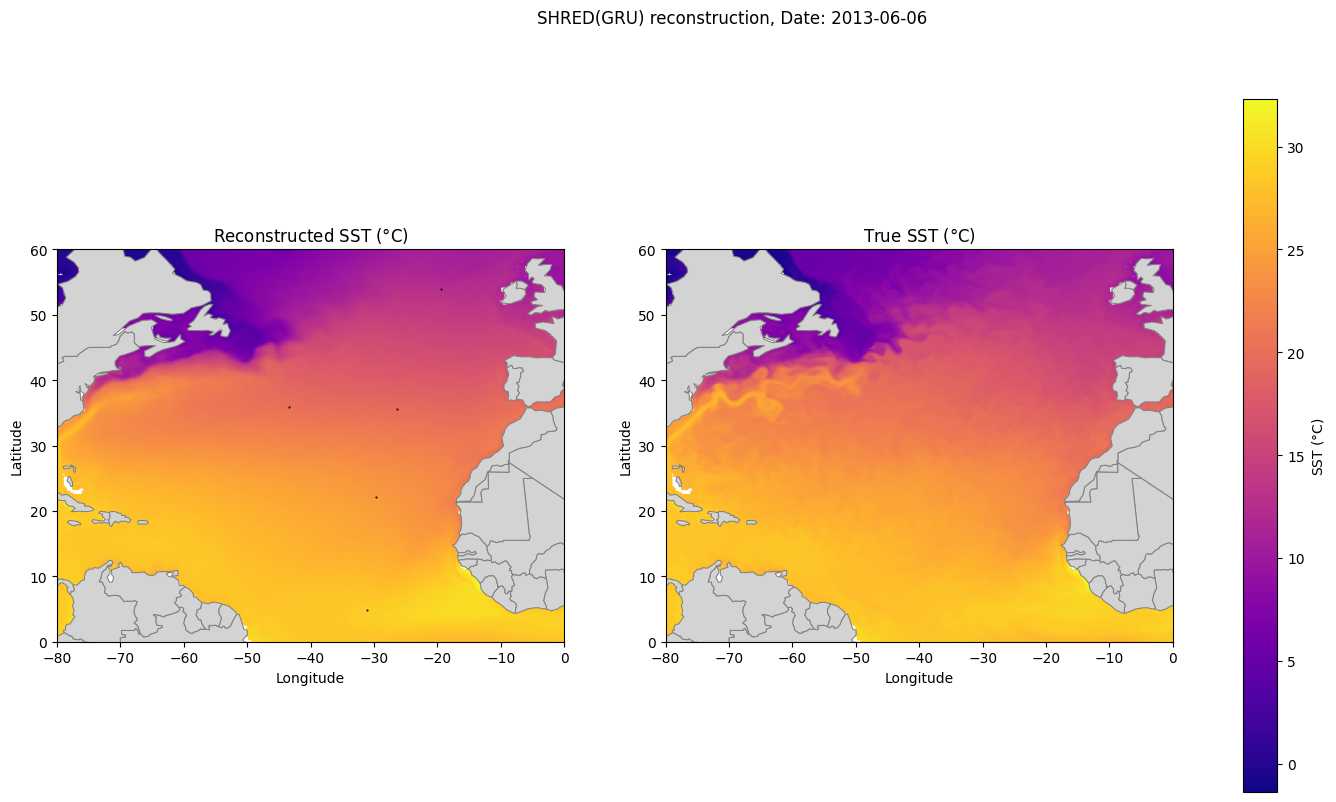

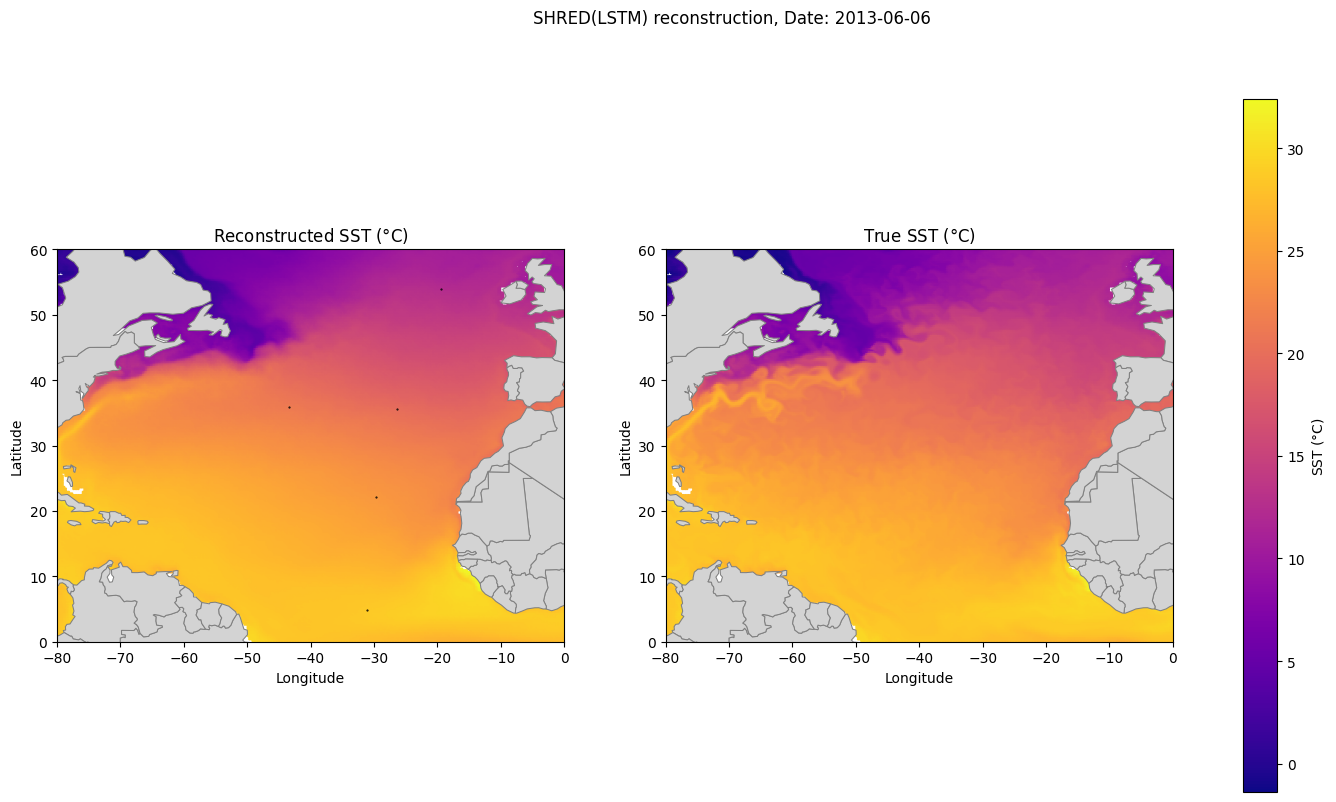

Date: 2014-11-27


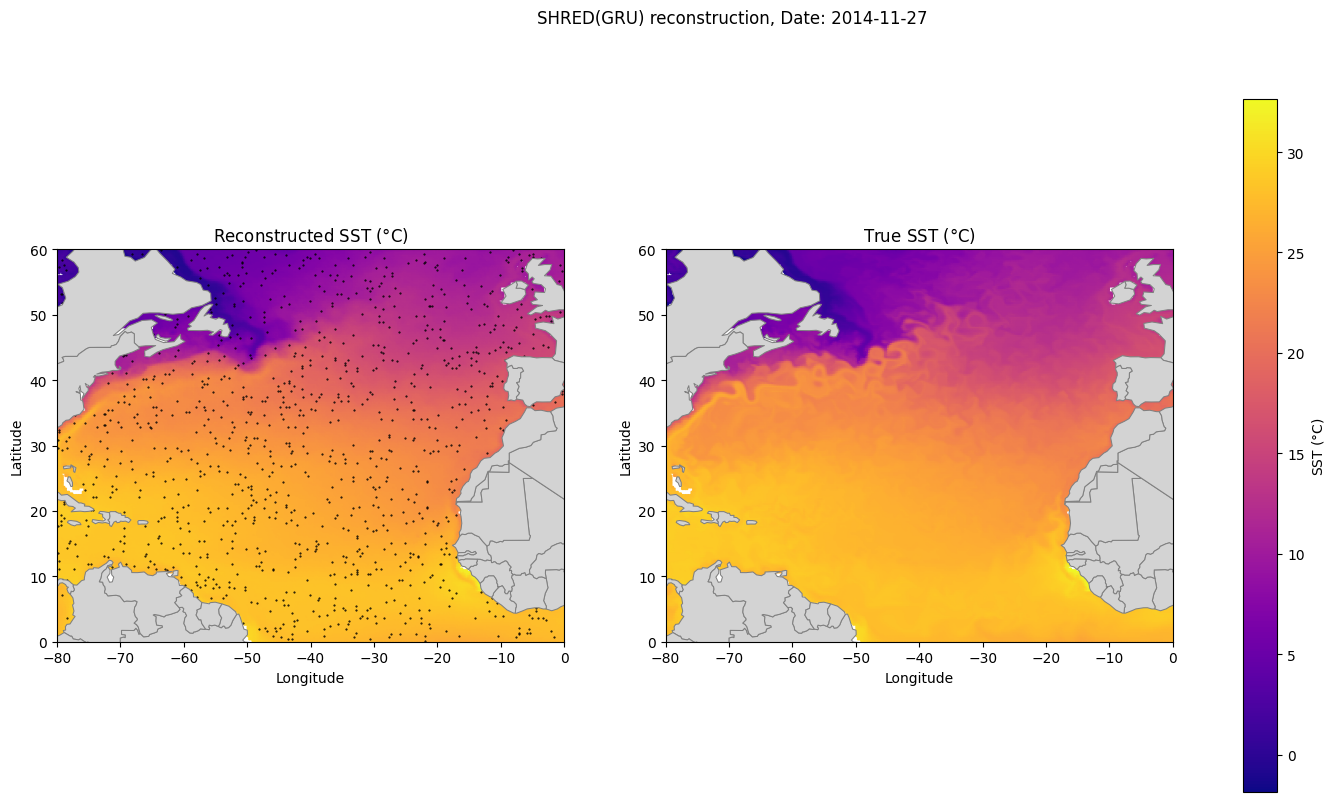

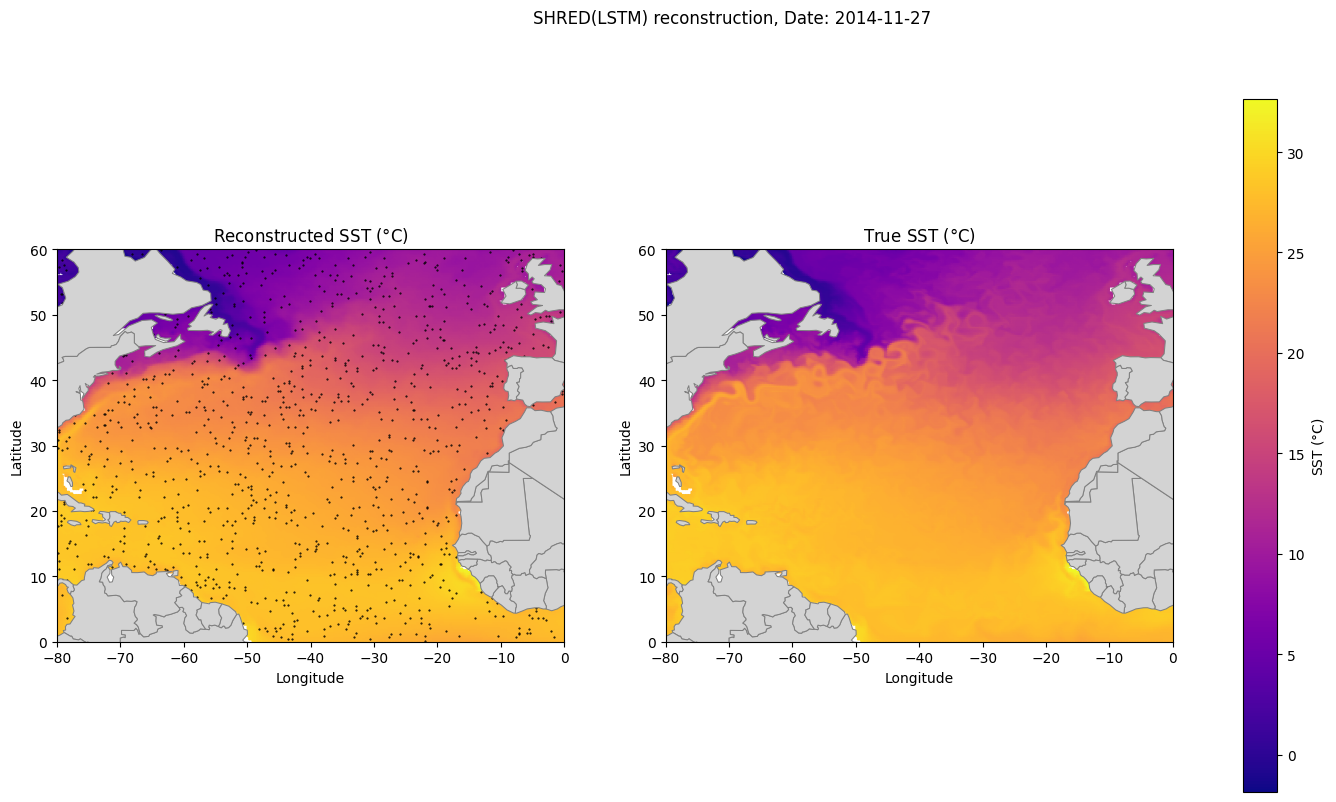

In [68]:
for (test_gru, test_lstm, truth, coords) in [(gru_test_recons_5, lstm_test_recons_5, GROUND_TRUTH, sensor_coords_5), 
                                          (gru_test_recons_1059, lstm_test_recons_1059, GROUND_TRUTH, sensor_coords_1059)]:
    for i in np.random.choice(range(len(test_gru)), 1):
        gru_df = pd.DataFrame({
            "Latitude": lats,
            "Longitude": longs,
            "SST": test_gru[i]
        })
        lstm_df = pd.DataFrame({
            "Latitude": lats,
            "Longitude": longs,
            "SST": test_lstm[i]
        })
        true_df = pd.DataFrame({
            "Latitude": lats,
            "Longitude": longs,
            "SST": truth[i]
        })
        date = TEST_LAG_DATES[i]
        print(f"Date: {date}")
        plot_compare_sst_recon(gru_df, true_df, area="NA", sensor_coords=coords, title=f"SHRED(GRU) reconstruction, Date: {date}")
        plot_compare_sst_recon(lstm_df, true_df, area="NA", sensor_coords=coords, title=f"SHRED(LSTM) reconstruction, Date: {date}")

### Metrics
Structural Similarity Index: [[1]](https://scikit-image.org/docs/stable/api/skimage.metrics.html#skimage.metrics.structural_similarity) [[2]](https://ieeexplore.ieee.org/document/4775883)



In [69]:
GROUND_TRUTH.shape

(183, 59063)

#### NA basin

In [70]:
for (num_sensors, test) in [(5, gru_test_recons_5), (1059, gru_test_recons_1059)]:
    print("NUM SENSORS: ", num_sensors, "TESTSET LAGS: ", lags)
    evaluate_metrics(test, GROUND_TRUTH)

NUM SENSORS:  5 TESTSET LAGS:  52
RMSE:	0.727
MSE:	0.529
NMSE:	0.001
MAE:	0.470
R2:	0.989
Average SSI:	0.949
NUM SENSORS:  1059 TESTSET LAGS:  52
RMSE:	0.647
MSE:	0.418
NMSE:	0.001
MAE:	0.408
R2:	0.992
Average SSI:	0.948


In [71]:
print("Calculation using 1059 sensors:")
for (model_name, num_sensors, test) in [("SHRED (GRU)", 1059, gru_test_recons_1059),
                                        ("SHRED (LSTM)", 1059, lstm_test_recons_1059),
                                        ("SDN", 1059, sdn_test_recons_1059)]:
    print("MODEL: ", model_name, "NUM SENSORS: ", num_sensors, "TESTSET LAGS: ", lags)
    evaluate_metrics(test, GROUND_TRUTH)

Calculation using 1059 sensors:
MODEL:  SHRED (GRU) NUM SENSORS:  1059 TESTSET LAGS:  52
RMSE:	0.647
MSE:	0.418
NMSE:	0.001
MAE:	0.408
R2:	0.992
Average SSI:	0.948
MODEL:  SHRED (LSTM) NUM SENSORS:  1059 TESTSET LAGS:  52
RMSE:	0.668
MSE:	0.446
NMSE:	0.001
MAE:	0.411
R2:	0.991
Average SSI:	0.948
MODEL:  SDN NUM SENSORS:  1059 TESTSET LAGS:  52
RMSE:	0.649
MSE:	0.421
NMSE:	0.001
MAE:	0.411
R2:	0.991
Average SSI:	0.946


#### Gulf-Stream region

In [72]:
for (num_sensors, test) in [(5, gru_test_recons_5), (1059, gru_test_recons_1059)]:
    print("NUM SENSORS: ", num_sensors, "TESTSET LAGS: ", lags)
    GS_test_data = mask_array_by_lat_long(test, lats, longs)
    GS_truth_data = mask_array_by_lat_long(GROUND_TRUTH, lats, longs)
    GS_test_data = [d[~np.isnan(d)] for d in GS_test_data]
    GS_truth_data = [d[~np.isnan(d)] for d in GS_truth_data]

    evaluate_metrics(GS_test_data, GS_truth_data)

NUM SENSORS:  5 TESTSET LAGS:  52
RMSE:	1.186
MSE:	1.408
NMSE:	0.004
MAE:	0.803
R2:	0.951
Average SSI:	0.846
NUM SENSORS:  1059 TESTSET LAGS:  52
RMSE:	1.103
MSE:	1.217
NMSE:	0.003
MAE:	0.745
R2:	0.959
Average SSI:	0.840


### Regional integral of SST (area weighted mean)

In [73]:
truth_sst_mean, _ = area_weighted_mean(GROUND_TRUTH, lats, longs)
# same truth for all data with matching sequence lengths (see beginning asserts)

# gru_test_sst_mean_5, _ = area_weighted_mean(gru_test_recons_5, lats, longs)
# lstm_test_sst_mean_5, _ = area_weighted_mean(lstm_test_recons_5, lats, longs)
# sdn_test_sst_mean_5, _ = area_weighted_mean(sdn_test_recons_5, lats, longs)

gru_test_sst_mean_1059, _ = area_weighted_mean(gru_test_recons_1059, lats, longs)
lstm_test_sst_mean_1059, _ = area_weighted_mean(lstm_test_recons_1059, lats, longs)
sdn_test_sst_mean_1059, _ = area_weighted_mean(sdn_test_recons_1059, lats, longs)

In [74]:
sst_mean_df = pd.DataFrame({
    "Date": TEST_LAG_DATES,
    # "SHRED (GRU) - 5 sensors": gru_test_sst_mean_5,
    "SHRED (GRU) - 1059 sensors": gru_test_sst_mean_1059,
    # "SHRED (LSTM) - 5 sensors": lstm_test_sst_mean_5,
    "SHRED (LSTM) - 1059 sensors": lstm_test_sst_mean_1059,
    # "SDN - 5 sensors": sdn_test_sst_mean_5,
    "SDN - 1059 sensors": sdn_test_sst_mean_1059,
    "Truth": truth_sst_mean
})
# Smooth over 1 year = 52 weeks
sst_rolling_df = pd.DataFrame({
    "Date": TEST_LAG_DATES,
    # "SHRED (GRU) - 5 sensors": sst_mean_df["SHRED (GRU) - 5 sensors"].rolling(52).mean(),
    "SHRED (GRU) - 1059 sensors": sst_mean_df["SHRED (GRU) - 1059 sensors"].rolling(52).mean(),
    # "SHRED (LSTM) - 5 sensors": sst_mean_df["SHRED (LSTM) - 5 sensors"].rolling(52).mean(),
    "SHRED (LSTM) - 1059 sensors": sst_mean_df["SHRED (LSTM) - 1059 sensors"].rolling(52).mean(),
    # "SDN - 5 sensors": sst_mean_df["SDN - 5 sensors"].rolling(52).mean(),
    "SDN - 1059 sensors": sst_mean_df["SDN - 1059 sensors"].rolling(52).mean(),
    "Truth": sst_mean_df.Truth.rolling(52).mean()
})
sst_mean_df = sst_mean_df.set_index("Date")
sst_rolling_df = sst_rolling_df.set_index("Date")

<Figure size 800x800 with 0 Axes>

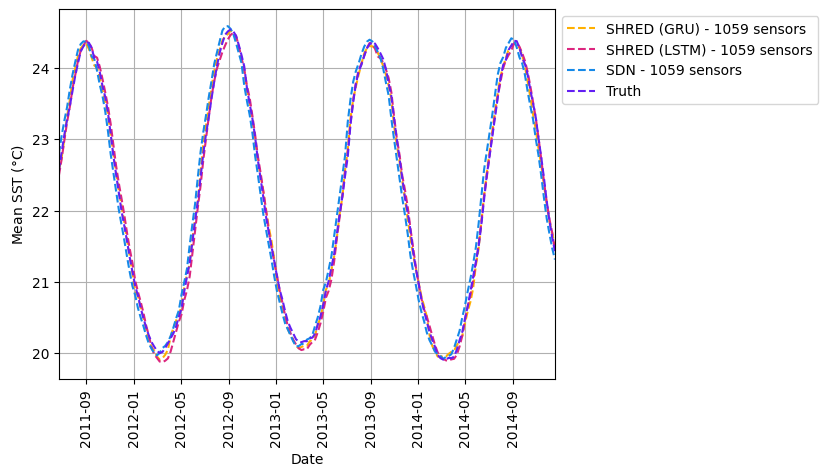

In [75]:
plt.figure(figsize=(8,8))
sst_mean_df[["SHRED (GRU) - 1059 sensors", "SHRED (LSTM) - 1059 sensors",
             "SDN - 1059 sensors", "Truth"]].plot(colormap=ListedColormap(colours[:4]), ls='--')
plt.xticks(rotation=90)
plt.ylabel("Mean SST ($\\degree$C)")
plt.xlim(TEST_LAG_DATES[0], TEST_LAG_DATES[-1])
plt.legend(bbox_to_anchor=(1,1))
plt.grid()
plt.show()

<Figure size 800x800 with 0 Axes>

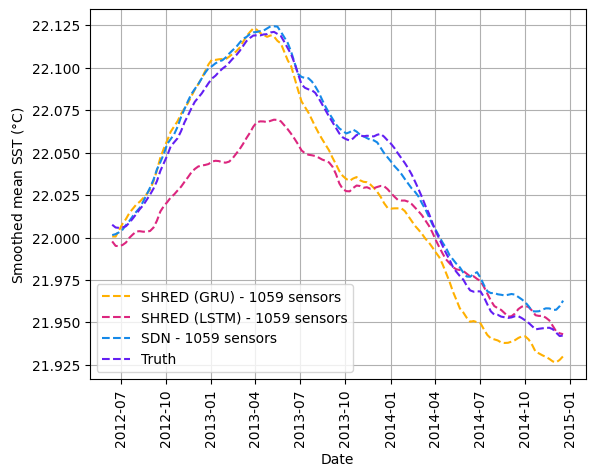

In [76]:
plt.figure(figsize=(8,8))
sst_rolling_df[["SHRED (GRU) - 1059 sensors", "SHRED (LSTM) - 1059 sensors",
             "SDN - 1059 sensors", "Truth"]].plot(colormap=ListedColormap(colours[:4]), ls='--')
plt.xticks(rotation=90)
plt.grid()
plt.ylabel("Smoothed mean SST ($\\degree$C)")
plt.show()

### Difference between test truth and reconstructions 

In [77]:
gru_difference_5 = gru_test_recons_5 - GROUND_TRUTH
lstm_difference_5 = lstm_test_recons_5 - GROUND_TRUTH
sdn_difference_5 = sdn_test_recons_5 - GROUND_TRUTH

gru_difference_1059 = gru_test_recons_1059 - GROUND_TRUTH
lstm_difference_1059 = lstm_test_recons_1059 - GROUND_TRUTH
sdn_difference_1059 = sdn_test_recons_1059 - GROUND_TRUTH

#### Difference plots

In [78]:
plot_index = 3

SHRED (GRU) - 5 sensors for date: 2011-07-14


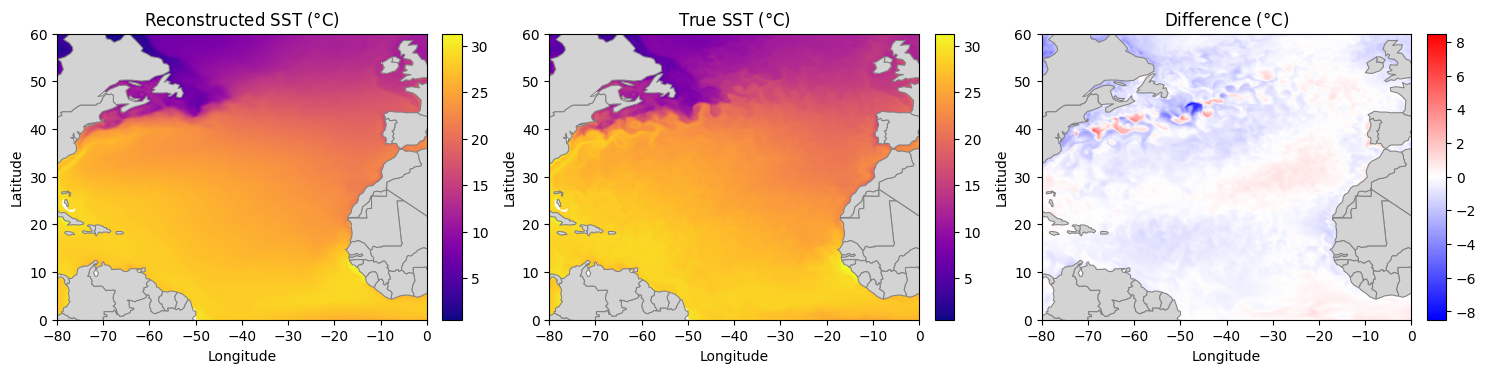

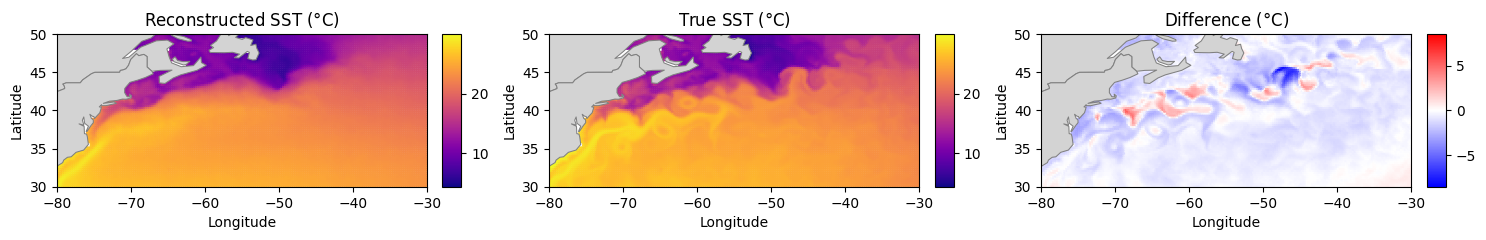

SHRED (GRU) - 1059 sensors for date: 2011-07-14


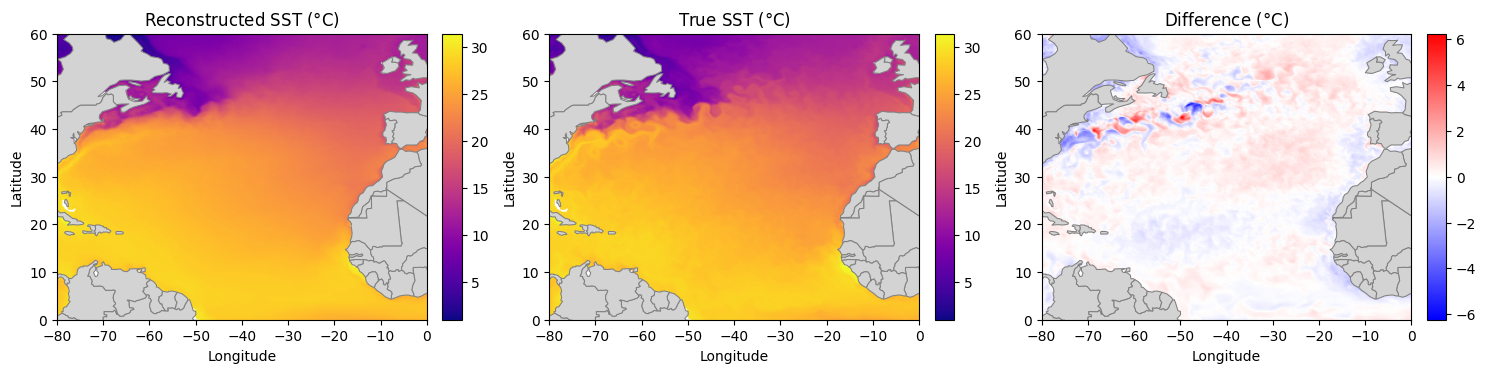

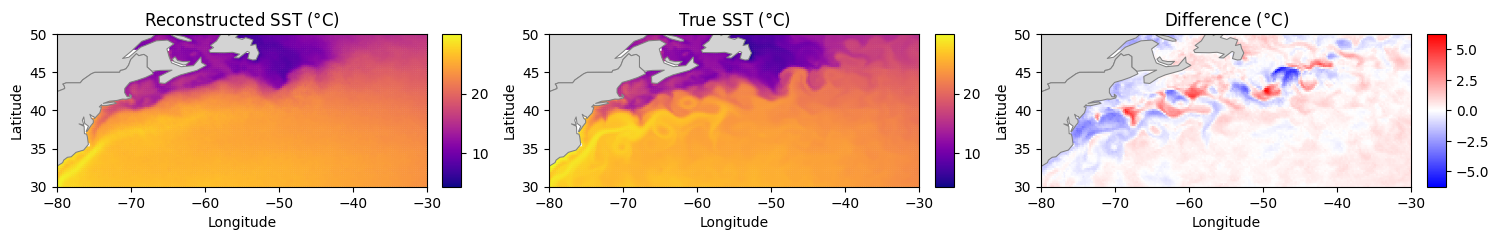

In [79]:
for (num_sensors, model_str, diff, test) in ([5, "SHRED (GRU)", gru_difference_5, gru_test_recons_5],
                                             [1059, "SHRED (GRU)", gru_difference_1059, gru_test_recons_1059]):
    for i in [plot_index]:  #range(0, len(test_recons), 10):  # np.random.choice(range(len(test_recons)), 1):
        diff_df = pd.DataFrame({
                "Latitude": lats,
                "Longitude": longs,
                "SST": diff[i]
            })
        recon_df = pd.DataFrame({
            "Latitude": lats,
            "Longitude": longs,
            "SST": test[i]
        })
        true_df = pd.read_csv(f"{NA_DATA_PATH}{TEST_LAG_DATES[i]}.csv")
        # plot_sst_map(diff_df, title=f"Difference map for {test_dates[i]}", min_sst=-5, max_sst=5, area="NA", cmap='bwr')
        print(f"{model_str} - {num_sensors} sensors for date: {TEST_LAG_DATES[i]}")
        plot_compare_sst_recon(recon_df, true_df, diff_data=diff_df, area="NA")  #, sensor_coords=sensor_coords)

        gs_recon_df = crop_df_to_area(recon_df, "GS", "Latitude")
        gs_true_df = crop_df_to_area(true_df, "GS", "Latitude")
        gs_diff_df = crop_df_to_area(diff_df, "GS", "Latitude")
        
        plot_compare_sst_recon(gs_recon_df, gs_true_df, diff_data=gs_diff_df, area='GS')

In [ ]:
min_sst = min([min(recon_df.SST), min(true_df.SST)])
max_sst = max([max(recon_df.SST), max(true_df.SST)])
print(TEST_LAG_DATES[i])

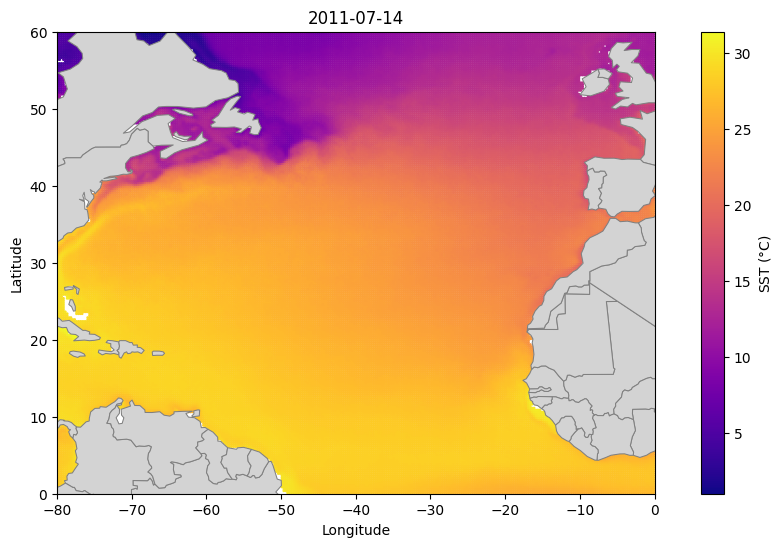

In [ ]:
plot_sst_map(recon_df, title="Reconstructed SST", min_sst=min(recon_df.SST), max_sst=max(recon_df.SST), area='NA')

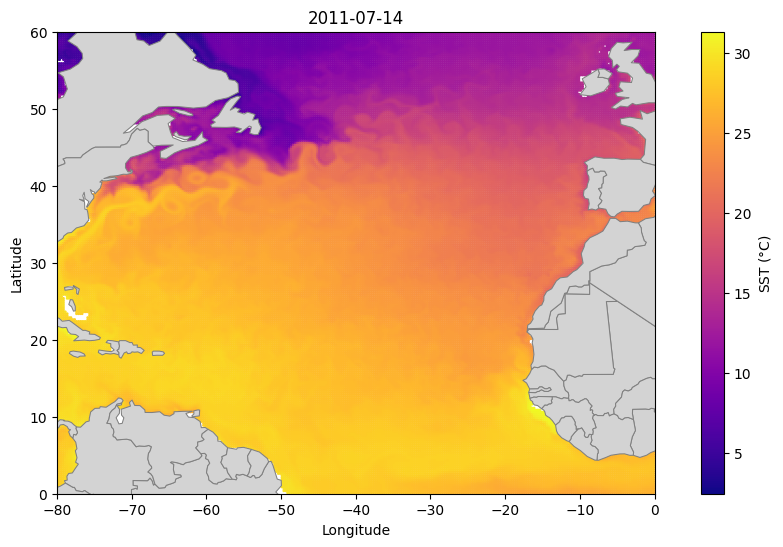

In [88]:
plot_sst_map(true_df, title=TEST_LAG_DATES[i], min_sst=min(true_df.SST), max_sst=max(true_df.SST), area='NA')

### Area-weighted average difference

In [ ]:
# gru_mean_diff_5, _ = area_weighted_mean(gru_difference_5, lats, longs)
# lstm_mean_diff_5, _ = area_weighted_mean(lstm_difference_5, lats, longs)
# sdn_mean_diff_5, _ = area_weighted_mean(sdn_difference_5, lats, longs)

gru_mean_diff_1059, _ = area_weighted_mean(gru_difference_1059, lats, longs)
lstm_mean_diff_1059, _ = area_weighted_mean(lstm_difference_1059, lats, longs)
sdn_mean_diff_1059, _ = area_weighted_mean(sdn_difference_1059, lats, longs)

In [ ]:
sst_diff_df = pd.DataFrame({
    "Date": TEST_LAG_DATES,
    # "SHRED (GRU) - 5 sensors": gru_mean_diff_5,
    "SHRED (GRU) - 1059 sensors": gru_mean_diff_1059,
    # "SHRED (LSTM) - 5 sensors": lstm_mean_diff_5,
    "SHRED (LSTM) - 1059 sensors": lstm_mean_diff_1059,
    # "SDN - 5 sensors": sdn_mean_diff_5,
    "SDN - 1059 sensors": sdn_mean_diff_1059,
})
# # Smooth over 1 year = 52 weeks
# sst_rolling_df = pd.DataFrame({
#     "Date": TEST_LAG_DATES,
#     # "SHRED (GRU) - 5 sensors": sst_mean_df["SHRED (GRU) - 5 sensors"].rolling(52).mean(),
#     "SHRED (GRU) - 1059 sensors": sst_mean_df["SHRED (GRU) - 1059 sensors"].rolling(52).mean(),
#     # "SHRED (LSTM) - 5 sensors": sst_mean_df["SHRED (LSTM) - 5 sensors"].rolling(52).mean(),
#     "SHRED (LSTM) - 1059 sensors": sst_mean_df["SHRED (LSTM) - 1059 sensors"].rolling(52).mean(),
#     # "SDN - 5 sensors": sst_mean_df["SDN - 5 sensors"].rolling(52).mean(),
#     "SDN - 1059 sensors": sst_mean_df["SDN - 1059 sensors"].rolling(52).mean(),
#     "Truth": sst_mean_df.Truth.rolling(52).mean()
# })
sst_diff_df = sst_diff_df.set_index("Date")
# sst_rolling_df = sst_rolling_df.set_index("Date")

<Figure size 800x800 with 0 Axes>

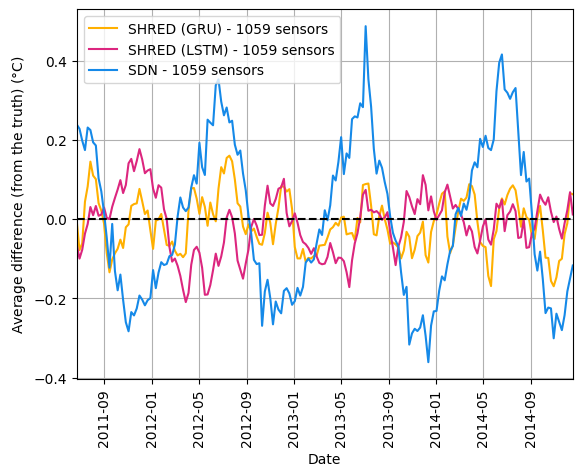

In [ ]:
plt.figure(figsize=(8,8))
sst_diff_df[["SHRED (GRU) - 1059 sensors", "SHRED (LSTM) - 1059 sensors",
             "SDN - 1059 sensors"]].plot(colormap=ListedColormap(colours[:3]), ls='-')
plt.xticks(rotation=90)
plt.hlines(0, TEST_LAG_DATES[0], TEST_LAG_DATES[-1], colors=['k'], linestyles=['--'])
plt.xlim(TEST_LAG_DATES[0], TEST_LAG_DATES[-1])
plt.ylabel("Average difference (from the truth) ($\\degree$C)")
plt.grid()
plt.show()

#### Zonally integrated average difference 
i.e. Average difference between reconstruction and truth across all years;
plotted against latitude (no weighting by area needed, because each square in latitude band has same area)

OR could scale by area by doing lat_band/total_area????

In [ ]:
avg_all_time_lat_avg_diffs = []
labels = []
for (num_sensors, model_str, difference) in [(5, "SHRED (GRU)", gru_difference_5),
                                              (1059, "SHRED (GRU)", gru_difference_1059),
                                              (5, "SHRED (LSTM)", lstm_difference_5),
                                              (1059, "SHRED (LSTM)", lstm_difference_1059),
                                              (5, "SDN", sdn_difference_5),
                                              (1059, "SDN", sdn_difference_1059)]:
    
    # For each reconstruction at a set date, find the average difference at each latitude
    latitude_avg_diffs = np.array([pd.Series(diff_at_time).groupby(lats).mean().to_numpy() for diff_at_time in difference])

    # For each latitude, calculate the mean difference over all time
    avg_all_time_lat_avg_diffs.append(np.array([np.mean(latitude_avg_diffs.T[j]) for j in range(latitude_avg_diffs.shape[1])]))
    labels.append(f"{model_str} - {num_sensors} sensors")

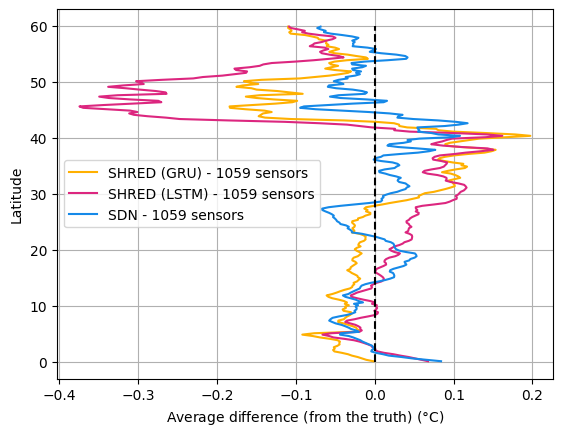

In [ ]:
colour_index = 0
for i in range(len(avg_all_time_lat_avg_diffs)):
    if "1059" in labels[i]:
        plt.plot(avg_all_time_lat_avg_diffs[i], np.unique(lats), c=colours[colour_index], label=labels[i])
        colour_index += 1
plt.vlines(0, 0, 60, colors=['k'], linestyles=['--'])
plt.xlabel('Average difference (from the truth) ($\\degree$C)')
plt.ylabel('Latitude')
plt.grid()
plt.legend()

#### Average difference between reconstruction and truth across whole NA region - by year

For 1059 sensor GRU model:

-0.014915452


Text(0.5, 0, 'Reconstruction date')

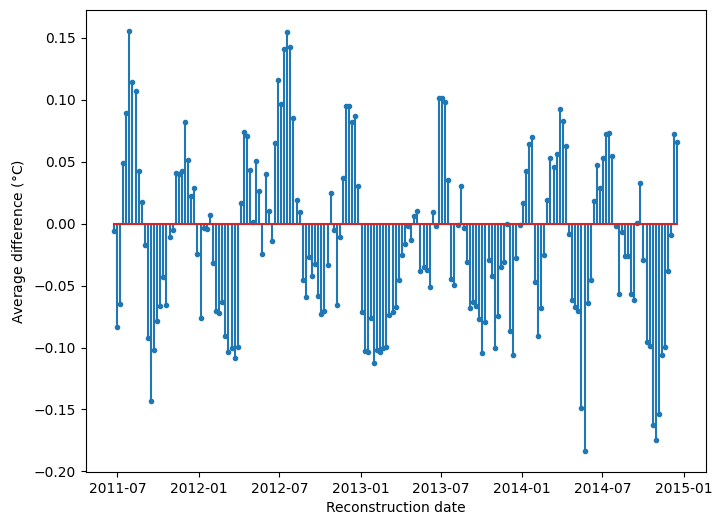

In [ ]:
avg_difference = [np.mean(d) for d in gru_difference_1059]
avg_all_time_difference = np.mean(avg_difference)
print(avg_all_time_difference)
plt.figure(figsize=(8,6))
plt.stem(TEST_LAG_DATES, avg_difference, markerfmt='.')
plt.ylabel('Average difference ($\\degree$C)')
plt.xlabel('Reconstruction date')

In [ ]:
# For Gulf Stream only:
GS_data = mask_array_by_lat_long(gru_difference_1059, lats, longs)
GS_data = [d[~np.isnan(d)] for d in GS_data]

-0.02116099


Text(0.5, 0, 'Reconstruction date')

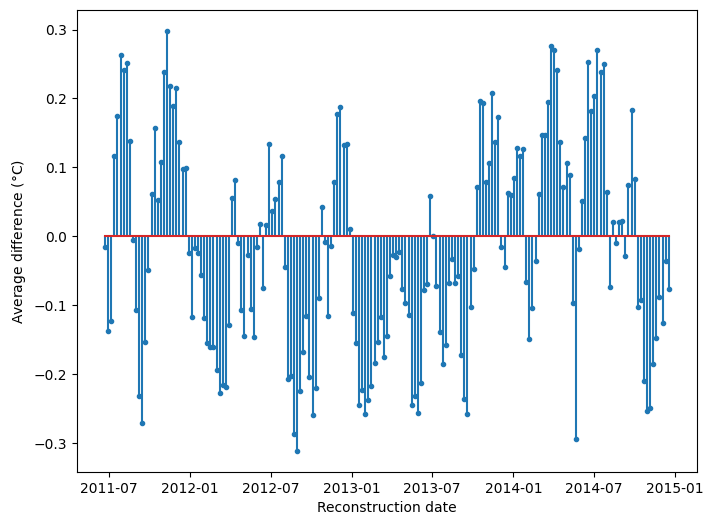

In [ ]:
avg_difference = [np.mean(d) for d in GS_data]
avg_all_time_difference = np.mean(avg_difference)
print(avg_all_time_difference)
plt.figure(figsize=(8,6))
plt.stem(TEST_LAG_DATES, avg_difference, markerfmt='.')
plt.ylabel('Average difference ($\\degree$C)')
plt.xlabel('Reconstruction date')